# Model dự báo MG95

Notebook này dùng các file đã chia `train/val/test` cho 3 horizon:

- `MG95_t_plus_1`
- `MG95_t_plus_3`
- `MG95_t_plus_7`

Nguyên tắc:
- Train dùng để học.
- Validation dùng để chọn model.
- Test chỉ dùng để đánh giá cuối cùng.
- Không shuffle dữ liệu vì đây là chuỗi thời gian.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Nếu chạy trên Google Colab thì mở comment 2 dòng dưới
# from google.colab import drive
# drive.mount('/content/drive')

import os
import glob
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# New models
import xgboost as xgb
import lightgbm as lgb

# Existing models (some will be replaced)
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
HORIZONS = [1, 3, 7]

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 1. Tìm thư mục chứa dữ liệu train/val/test

Notebook sẽ tự tìm thư mục `Data_Train_Val_Test` trong `DACS_2`.

Nếu không tìm thấy, bạn chỉ cần sửa biến `SPLIT_ROOT` thành đường dẫn thư mục chứa 3 folder:

```text
MG95_t_plus_1/
MG95_t_plus_3/
MG95_t_plus_7/
```


In [ ]:
# Cách 1: tự tìm trong Google Drive
SEARCH_ROOT = "/content/drive/MyDrive/DACS_2"

candidates = glob.glob(
    os.path.join(SEARCH_ROOT, "**", "Data_Train_Val_Test"),
    recursive=True
)

if len(candidates) > 0:
    SPLIT_ROOT = candidates[0]
else:
    # Nếu chạy ngoài Colab hoặc không tự tìm thấy, sửa dòng này thủ công
    SPLIT_ROOT = "Data_Train_Val_Test"

print("SPLIT_ROOT:", SPLIT_ROOT)
print("Tồn tại chưa:", os.path.exists(SPLIT_ROOT))

if os.path.exists(SPLIT_ROOT):
    print("Các thư mục/file bên trong:")
    for item in os.listdir(SPLIT_ROOT):
        print("-", item)


SPLIT_ROOT: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test
Tồn tại chưa: True
Các thư mục/file bên trong:
- MG95_t_plus_1
- MG95_t_plus_3
- MG95_t_plus_7
- model_results_all_horizons.csv


## 2. Hàm đọc dữ liệu cho từng horizon

In [ ]:
def find_horizon_folder(split_root, horizon):
    """Tìm folder MG95_t_plus_h trong SPLIT_ROOT."""
    direct = os.path.join(split_root, f"MG95_t_plus_{horizon}")
    if os.path.exists(direct):
        return direct

    matches = glob.glob(
        os.path.join(split_root, f"*t_plus_{horizon}*")
    )
    matches = [m for m in matches if os.path.isdir(m)]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Không tìm thấy folder cho t+{horizon} trong: {split_root}"
        )

    return matches[0]


def load_split_data(split_root, horizon):
    """Đọc train.csv, val.csv, test.csv cho horizon h."""
    folder = find_horizon_folder(split_root, horizon)

    train_path = os.path.join(folder, "train.csv")
    val_path = os.path.join(folder, "val.csv")
    test_path = os.path.join(folder, "test.csv")

    for p in [train_path, val_path, test_path]:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Thiếu file: {p}")

    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    for df in [train_df, val_df, test_df]:
        if "Date" in df.columns:
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    target_col = f"MG95_t_+_{horizon}" # Fixed: Changed _plus_ to _+_

    if target_col not in train_df.columns:
        print(f"DEBUG: Các cột trong train.csv cho horizon t+{horizon}: {train_df.columns.tolist()}")
        raise ValueError(f"Không thấy target {target_col} trong train.csv")

    feature_cols = [
        col for col in train_df.columns
        if col not in ["Date", target_col]
    ]

    # Chỉ lấy feature dạng số để tránh lỗi model
    numeric_feature_cols = train_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

    return {
        "horizon": horizon,
        "folder": folder,
        "target_col": target_col,
        "feature_cols": numeric_feature_cols,
        "train": train_df,
        "val": val_df,
        "test": test_df
    }


# Kiểm tra nhanh 3 bộ dữ liệu
for h in HORIZONS:
    data = load_split_data(SPLIT_ROOT, h)
    print(f"\n===== t+{h} =====")
    print("Folder:", data["folder"])
    print("Target:", data["target_col"])
    print("Số feature:", len(data["feature_cols"]))
    print("Train:", data["train"].shape)
    print("Val  :", data["val"].shape)
    print("Test :", data["test"].shape)
    if "Date" in data["train"].columns:
        print("Train date:", data["train"]["Date"].min(), "→", data["train"]["Date"].max())
        print("Val date  :", data["val"]["Date"].min(), "→", data["val"]["Date"].max())
        print("Test date :", data["test"]["Date"].min(), "→", data["test"]["Date"].max())


===== t+1 =====
Folder: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_1
Target: MG95_t_+_1
Số feature: 22
Train: (2798, 23)
Val  : (600, 23)
Test : (600, 23)

===== t+3 =====
Folder: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_3
Target: MG95_t_+_3
Số feature: 22
Train: (2797, 23)
Val  : (599, 23)
Test : (600, 23)

===== t+7 =====
Folder: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_7
Target: MG95_t_+_7
Số feature: 22
Train: (2794, 23)
Val  : (599, 23)
Test : (599, 23)


## 3. Metrics đánh giá model

In [ ]:
def evaluate_regression(y_true, y_pred):
    """Tính các chỉ số đánh giá hồi quy."""
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # MAPE tránh chia cho 0
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_%": mape,
        "R2": r2
    }


## 4. Khai báo model

Các model dùng trước:

1. **Naive baseline**: lấy giá gần nhất làm dự báo.
2. **Ridge Regression**: baseline tuyến tính có regularization.
3. **Random Forest**: model phi tuyến, có giới hạn độ sâu để giảm overfitting.
4. **HistGradientBoosting**: boosting model trong sklearn.
5. **SVR**: model phi tuyến, cần scale.

Sau khi có kết quả này, nếu cần mới chạy LSTM riêng.


In [ ]:
def get_models():
    models = {
        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),

        "XGBoost": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", xgb.XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),

        "LightGBM": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", lgb.LGBMRegressor(
                n_estimators=300,
                learning_rate=0.05,
                num_leaves=31,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),

    }

    return models


## 5. Train model cho 1 horizon

In [ ]:
def train_one_horizon(split_root, horizon):
    data = load_split_data(split_root, horizon)

    target_col = data["target_col"]
    feature_cols = data["feature_cols"]

    train_df = data["train"].dropna(subset=[target_col]).copy()
    val_df = data["val"].dropna(subset=[target_col]).copy()
    test_df = data["test"].dropna(subset=[target_col]).copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_val = val_df[feature_cols]
    y_val = val_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    results = []
    predictions = {}

    # Naive baseline: ưu tiên MG95_lag1
    baseline_col = None
    if "MG95_lag1" in feature_cols:
        baseline_col = "MG95_lag1"
    else:
        mg95_lag_cols = [c for c in feature_cols if "MG95" in c and "lag" in c.lower()]
        if len(mg95_lag_cols) > 0:
            baseline_col = mg95_lag_cols[0]

    if baseline_col is not None:
        for split_name, X_split, y_split in [
            ("train", X_train, y_train),
            ("val", X_val, y_val),
            ("test", X_test, y_test)
        ]:
            y_pred = X_split[baseline_col].values
            metrics = evaluate_regression(y_split, y_pred)
            results.append({
                "Horizon": horizon,
                "Model": f"Naive_{baseline_col}",
                "Split": split_name,
                **metrics
            })

        predictions[f"Naive_{baseline_col}"] = X_test[baseline_col].values

    # ML models
    models = get_models()

    trained_models = {}

    for model_name, model in models.items():
        print(f"Training t+{horizon} - {model_name} ...")

        model.fit(X_train, y_train)
        trained_models[model_name] = model

        for split_name, X_split, y_split in [
            ("train", X_train, y_train),
            ("val", X_val, y_val),
            ("test", X_test, y_test)
        ]:
            y_pred = model.predict(X_split)
            metrics = evaluate_regression(y_split, y_pred)

            results.append({
                "Horizon": horizon,
                "Model": model_name,
                "Split": split_name,
                **metrics
            })

        predictions[model_name] = model.predict(X_test)

    results_df = pd.DataFrame(results)

    # Chọn model tốt nhất theo Validation RMSE
    val_results = results_df[results_df["Split"] == "val"].copy()
    best_row = val_results.sort_values("RMSE").iloc[0]
    best_model_name = best_row["Model"]

    print(f"\nBest model t+{horizon} theo Validation RMSE:", best_model_name)
    print(best_row)

    # Lưu model tốt nhất nếu không phải naive
    output_folder = data["folder"]
    model_folder = os.path.join(output_folder, "models")
    os.makedirs(model_folder, exist_ok=True)

    if best_model_name in trained_models:
        model_path = os.path.join(model_folder, f"best_model_t_plus_{horizon}_{best_model_name}.pkl")
        joblib.dump({
            "model": trained_models[best_model_name],
            "feature_cols": feature_cols,
            "target_col": target_col,
            "horizon": horizon
        }, model_path)
        print("Đã lưu model:", model_path)
    else:
        print("Best model là Naive baseline nên không lưu file .pkl")

    # Lưu kết quả
    results_path = os.path.join(output_folder, f"model_results_t_plus_{horizon}.csv")
    results_df.to_csv(results_path, index=False, encoding="utf-8-sig")
    print("Đã lưu kết quả:", results_path)

    # Lưu dự báo test của model tốt nhất
    pred_df = pd.DataFrame()
    if "Date" in test_df.columns:
        pred_df["Date"] = test_df["Date"]

    pred_df["Actual"] = y_test.values
    pred_df["Predicted"] = predictions[best_model_name]
    pred_df["Error"] = pred_df["Actual"] - pred_df["Predicted"]
    pred_df["Best_Model"] = best_model_name
    pred_df["Horizon"] = horizon

    pred_path = os.path.join(output_folder, f"test_predictions_t_plus_{horizon}.csv")
    pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")
    print("Đã lưu dự báo test:", pred_path)

    return results_df, pred_df, best_model_name


## 6. Chạy model cho t+1, t+3, t+7

In [ ]:
all_results = []
all_predictions = {}
best_models = {}

for h in HORIZONS:
    print("\n" + "=" * 80)
    print(f"CHẠY MODEL CHO MG95 t+{h}")
    print("=" * 80)

    results_df, pred_df, best_model_name = train_one_horizon(SPLIT_ROOT, h)

    all_results.append(results_df)
    all_predictions[h] = pred_df
    best_models[h] = best_model_name

final_results = pd.concat(all_results, ignore_index=True)

display(final_results.sort_values(["Horizon", "Split", "RMSE"]))
print("Best models:", best_models)



CHẠY MODEL CHO MG95 t+1
Training t+1 - RandomForest ...
Training t+1 - XGBoost ...
Training t+1 - LightGBM ...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000680 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3348
[LightGBM] [Info] Number of data points in the train set: 2798, number of used features: 21
[LightGBM] [Info] Start training from score 87.178292

Best model t+1 theo Validation RMSE: LightGBM
Horizon           1
Model      LightGBM
Split           val
RMSE       3.703508
MAE        2.071272
MAPE_%     2.032034
R2         0.982171
Name: 10, dtype: object
Đã lưu model: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_1/models/best_model_t_plus_1_LightGBM.pkl
Đã lưu kết quả: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_1/model_results_t_plus_1.csv
Đã lưu dự báo test: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/MG95_t_plus_1/test_predic

,Horizon,Model,Split,RMSE,MAE,MAPE_%,R2
11,1,LightGBM,test,1.505656,1.160770,1.271366,0.976273
8,1,XGBoost,test,1.511611,1.149260,1.256954,0.976084
5,1,RandomForest,test,1.717476,1.274369,1.395247,0.969127
2,1,Naive_MG95_lag1,test,2.345431,1.804333,1.988513,0.942423
6,1,XGBoost,train,0.528298,0.401742,0.500138,0.999623
9,1,LightGBM,train,0.636910,0.486604,0.628267,0.999452
3,1,RandomForest,train,1.225604,0.884740,1.180211,0.997971
0,1,Naive_MG95_lag1,train,2.421741,1.816569,2.388627,0.992076
10,1,LightGBM,val,3.703508,2.071272,2.032034,0.982171
1,1,Naive_MG95_lag1,val,3.830565,2.616700,2.772952,0.980927


Best models: {1: 'LightGBM', 3: 'Naive_MG95_lag1', 7: 'Naive_MG95_lag1'}


## 7. Bảng so sánh Validation và Test

In [ ]:
summary = final_results[
    final_results["Split"].isin(["val", "test"])
].copy()

summary_pivot = summary.pivot_table(
    index=["Horizon", "Model"],
    columns="Split",
    values=["RMSE", "MAE", "MAPE_%", "R2"]
)

display(summary_pivot)

# Lưu bảng tổng hợp
summary_path = os.path.join(SPLIT_ROOT, "model_results_all_horizons.csv")
final_results.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("Đã lưu bảng tổng hợp:", summary_path)


MAE              MAPE_%                  R2                RMSE          
Split                        test       val      test       val      test       val      test       val
Horizon Model                                                                                          
1       LightGBM         1.160770  2.071272  1.271366  2.032034  0.976273  0.982171  1.505656  3.703508
        Naive_MG95_lag1  1.804333  2.616700  1.988513  2.772952  0.942423  0.980927  2.345431  3.830565
        RandomForest     1.274369  2.343642  1.395247  2.299546  0.969127  0.980040  1.717476  3.918618
        XGBoost          1.149260  2.252703  1.256954  2.201163  0.976084  0.978775  1.511611  4.040911
3       LightGBM         2.951650  3.915731  3.223087  3.956949  0.856542  0.954923  3.690122  5.912137
        Naive_MG95_lag1  2.547967  3.548314  2.813393  3.774186  0.883332  0.965166  3.327780  5.197190
        RandomForest     2.434008  3.733642  2.671935  3.776362  0.896001  0.961126  3.141902  5.490337
        XGBoost          2.554405  3.960621  2.809626  4.061238  0.886048  0.954927  3.288816  5.911871
7       LightGBM         4.754031  5.826460  5.226677  6.100773  0.625449  0.914371  5.911205  8.123867
        Naive_MG95_lag1  3.396110  4.884207  3.744935  5.237248  0.793313  0.937468  4.391135  6.942329
        RandomForest     3.929250  5.684904  4.309267  5.844970  0.721585  0.917151  5.096434  7.990906
        XGBoost          4.365790  6.373795  4.800194  6.660623  0.664214  0.889864  5.596955  9.213355

Đã lưu bảng tổng hợp: /content/drive/MyDrive/DACS_2/data/Data_Train_Val_Test/model_results_all_horizons.csv


## 8. Vẽ Actual vs Predicted trên tập Test

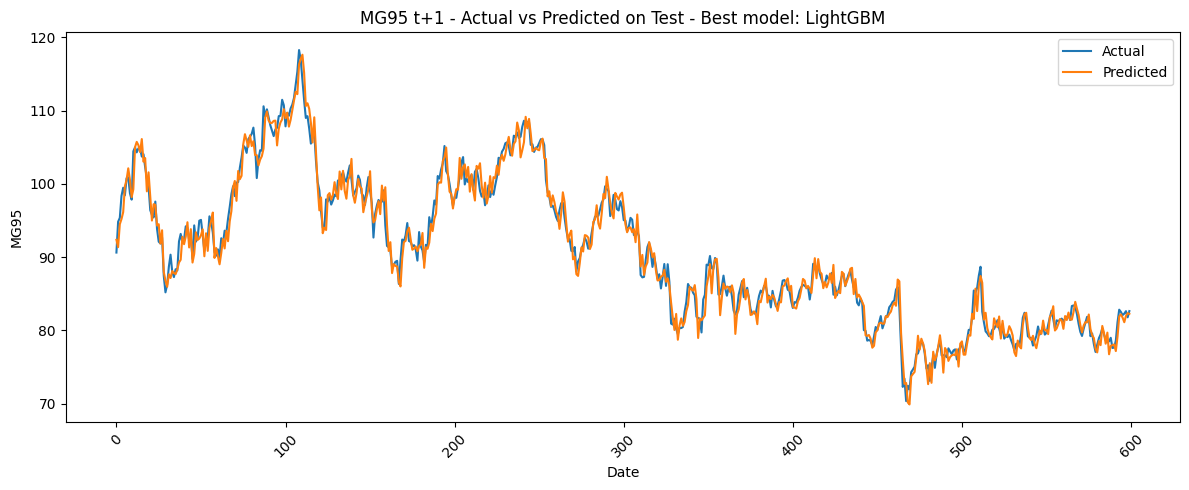

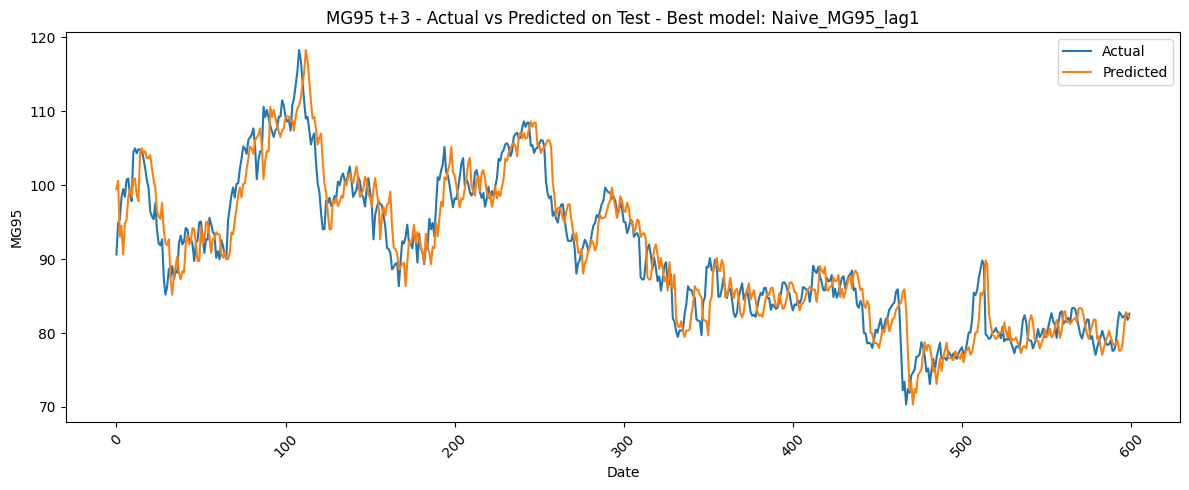

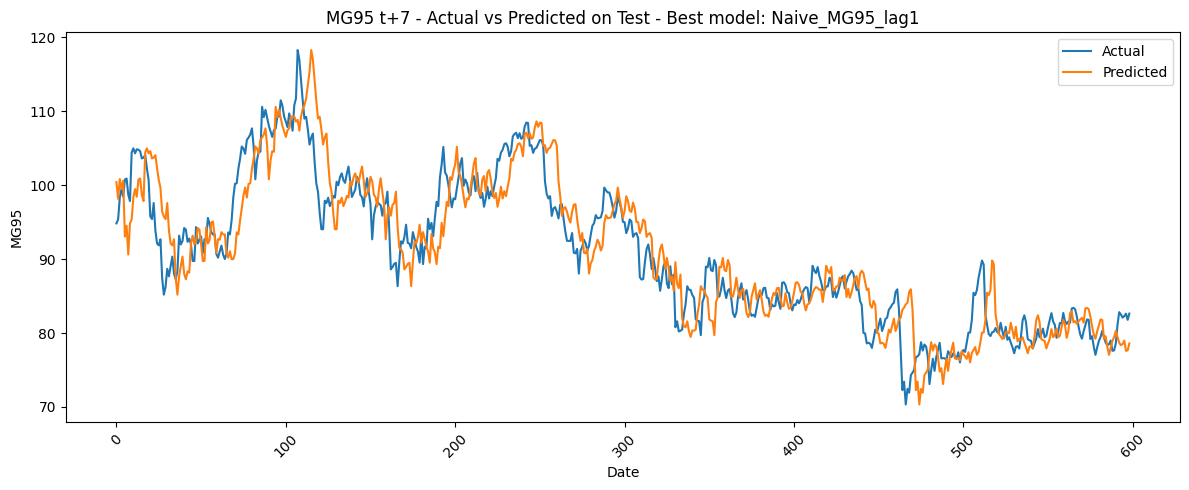

In [ ]:
for h, pred_df in all_predictions.items():
    plt.figure(figsize=(12, 5))

    if "Date" in pred_df.columns:
        x_axis = pred_df["Date"]
    else:
        x_axis = range(len(pred_df))

    plt.plot(x_axis, pred_df["Actual"], label="Actual")
    plt.plot(x_axis, pred_df["Predicted"], label="Predicted")

    plt.title(f"MG95 t+{h} - Actual vs Predicted on Test - Best model: {best_models[h]}")
    plt.xlabel("Date")
    plt.ylabel("MG95")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 9. Nhận xét overfitting

Nhìn bảng kết quả:

- Nếu RMSE train thấp hơn rất nhiều so với val/test → model bị overfitting.
- Nếu train, val, test đều cao → model đang underfitting hoặc feature chưa đủ tốt.
- Chọn model dựa trên validation, sau đó báo cáo kết quả cuối cùng trên test.

Không dùng test để chỉnh model.


In [ ]:
# Bảng kiểm tra gap train - val - test theo RMSE
rmse_table = final_results.pivot_table(
    index=["Horizon", "Model"],
    columns="Split",
    values="RMSE"
).reset_index()

if {"train", "val", "test"}.issubset(rmse_table.columns):
    rmse_table["val_train_gap"] = rmse_table["val"] - rmse_table["train"]
    rmse_table["test_train_gap"] = rmse_table["test"] - rmse_table["train"]

display(rmse_table.sort_values(["Horizon", "val"]))


Split,Horizon,Model,test,train,val,val_train_gap,test_train_gap
0,1,LightGBM,1.505656,0.636910,3.703508,3.066597,0.868745
1,1,Naive_MG95_lag1,2.345431,2.421741,3.830565,1.408824,-0.076310
2,1,RandomForest,1.717476,1.225604,3.918618,2.693015,0.491872
3,1,XGBoost,1.511611,0.528298,4.040911,3.512613,0.983313
5,3,Naive_MG95_lag1,3.327780,3.426262,5.197190,1.770928,-0.098482
6,3,RandomForest,3.141902,2.080705,5.490337,3.409631,1.061197
7,3,XGBoost,3.288816,1.016418,5.911871,4.895452,2.272398
4,3,LightGBM,3.690122,1.189970,5.912137,4.722167,2.500152
9,7,Naive_MG95_lag1,4.391135,5.085066,6.942329,1.857263,-0.693932
10,7,RandomForest,5.096434,3.049074,7.990906,4.941832,2.047359


## 10. Triển khai mô hình LSTM

Mô hình LSTM (Long Short-Term Memory) là một loại mạng nơ-ron hồi quy (RNN) đặc biệt, rất hiệu quả trong việc xử lý và dự đoán các chuỗi thời gian.

Vì LSTM yêu cầu dữ liệu phải được định dạng theo chuỗi, chúng ta cần một bước tiền xử lý riêng biệt để tạo ra các cửa sổ dữ liệu (sequences) từ tập dữ liệu ban đầu. Sau đó, chúng ta sẽ xây dựng một mô hình LSTM đơn giản và huấn luyện nó.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow Version: {tf.__version__}")


TensorFlow Version: 2.20.0


### 10.1. Chuẩn bị dữ liệu cho LSTM

Để sử dụng LSTM, chúng ta cần chuyển đổi dữ liệu thành dạng chuỗi (sequences) có độ dài nhất định. Mỗi `horizon` sẽ có một bộ dữ liệu riêng và chúng ta sẽ xử lý cho `t+1` trước.

Đầu tiên, chúng ta cần tái cấu trúc hàm `load_split_data` một chút hoặc load lại dữ liệu để lấy `train_df`, `val_df`, `test_df` gốc (chưa xử lý `dropna` hay lọc `numeric_feature_cols`) để đảm bảo chúng ta có đủ dữ liệu chuỗi.


In [ ]:
def create_sequences(data, target_col, feature_cols, sequence_length):
    xs, ys = [], []
    # Đảm bảo dữ liệu được sắp xếp theo thời gian nếu có cột 'Date'
    if 'Date' in data.columns:
        data = data.sort_values('Date').reset_index(drop=True)

    # Điền thiếu các giá trị số bằng trung vị trước khi tạo chuỗi
    imputer = SimpleImputer(strategy='median')
    data[feature_cols] = imputer.fit_transform(data[feature_cols])

    # Chuẩn hóa dữ liệu
    scaler = StandardScaler()
    data[feature_cols] = scaler.fit_transform(data[feature_cols])

    for i in range(len(data) - sequence_length):
        # Lấy feature từ `i` đến `i + sequence_length`
        x = data.iloc[i:(i + sequence_length)][feature_cols].values
        # Target là giá trị `target_col` tại `i + sequence_length`
        y = data.iloc[i + sequence_length][target_col]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys), scaler, imputer


# Chọn một horizon để thử nghiệm LSTM
h_lstm = 1
data_lstm = load_split_data(SPLIT_ROOT, h_lstm)

train_df_lstm = data_lstm["train"]
val_df_lstm = data_lstm["val"]
test_df_lstm = data_lstm["test"]

target_col_lstm = data_lstm["target_col"]
feature_cols_lstm = data_lstm["feature_cols"]

SEQUENCE_LENGTH = 10 # Độ dài của chuỗi đầu vào

# Tạo chuỗi cho tập train, val, test
X_train_lstm, y_train_lstm, scaler_lstm, imputer_lstm = create_sequences(train_df_lstm, target_col_lstm, feature_cols_lstm, SEQUENCE_LENGTH)
X_val_lstm, y_val_lstm, _, _ = create_sequences(val_df_lstm, target_col_lstm, feature_cols_lstm, SEQUENCE_LENGTH)
X_test_lstm, y_test_lstm, _, _ = create_sequences(test_df_lstm, target_col_lstm, feature_cols_lstm, SEQUENCE_LENGTH)

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_val_lstm shape: {X_val_lstm.shape}")
print(f"y_val_lstm shape: {y_val_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")


X_train_lstm shape: (2788, 10, 22)
y_train_lstm shape: (2788,)
X_val_lstm shape: (590, 10, 22)
y_val_lstm shape: (590,)
X_test_lstm shape: (590, 10, 22)
y_test_lstm shape: (590,)


### 10.2. Xây dựng và huấn luyện mô hình LSTM

Chúng ta sẽ xây dựng một mô hình LSTM đơn giản với một vài lớp LSTM và Dense. Để tránh overfitting, chúng ta sẽ thêm Dropout và sử dụng EarlyStopping.


In [ ]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=1)  # Output đơn giá trị cho hồi quy
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Xây dựng model
input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2]) # (sequence_length, num_features)
lstm_model = build_lstm_model(input_shape)
lstm_model.summary()

# Callbacks cho huấn luyện
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

# Huấn luyện model
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=30, # Có thể tăng epochs nếu cần, EarlyStopping sẽ dừng sớm
    batch_size=32,
    validation_data=(X_val_lstm, y_val_lstm),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 50)         │        14,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,851 (136.14 KB)

 Trainable params: 34,851 (136.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 7187.0601 - val_loss: 6614.8940 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 5770.3062 - val_loss: 5829.2471 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 5096.0439 - val_loss: 5193.2100 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4531.9062 - val_loss: 4634.5210 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4028.1829 - val_loss: 4142.4209 - learning_rate: 0.0010
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3597.2705 - val_loss: 3705.6580 - learning_rate: 0.0010
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3206.5813 - val_loss: 3314.4414 - learning_rate: 0.0010
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2856.2888 - val_loss: 2966.7363 - learning_rate: 0.0010
Epoch 9/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2551.1780 - val_loss:

### 10.3. Đánh giá mô hình LSTM

Sau khi huấn luyện, chúng ta sẽ đánh giá hiệu suất của mô hình LSTM trên tập test và so sánh với các mô hình Machine Learning khác.


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

===== Đánh giá mô hình LSTM (t+1) =====
RMSE: 14.3387
MAE: 12.1586
MAPE_%: 14.0744
R2: -1.1367


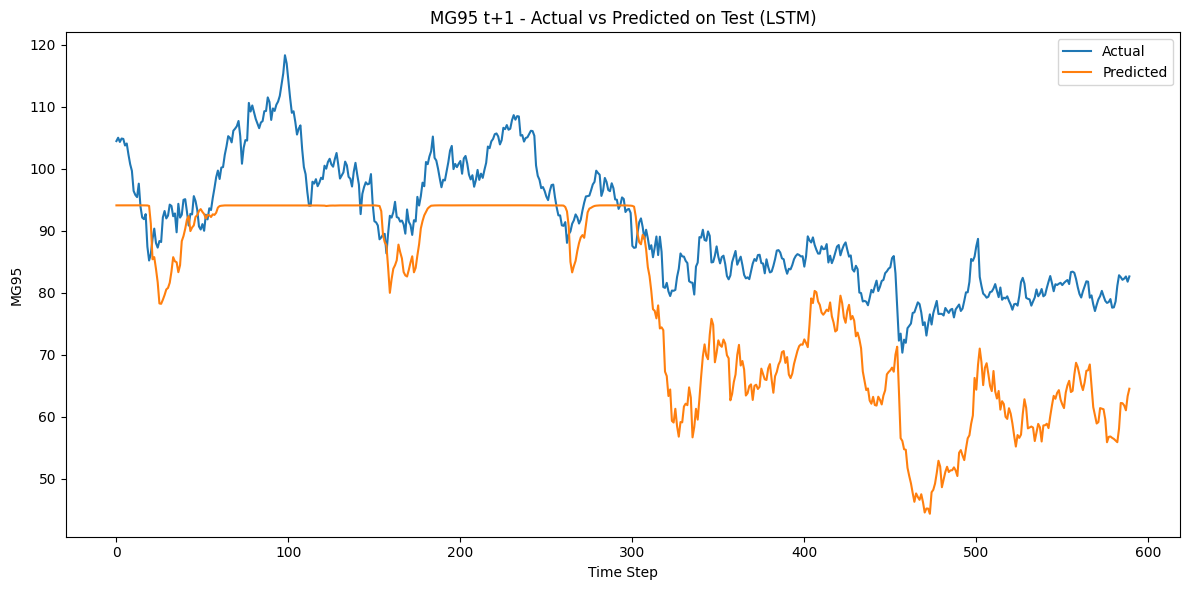

In [ ]:
# Dự đoán trên tập test
y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

# Đánh giá
metrics_lstm = evaluate_regression(y_test_lstm, y_pred_lstm)

print("\n===== Đánh giá mô hình LSTM (t+1) =====")
for metric, value in metrics_lstm.items():
    print(f"{metric}: {value:.4f}")

# Visualize Actual vs Predicted cho LSTM
plt.figure(figsize=(12, 6))
plt.plot(y_test_lstm, label="Actual")
plt.plot(y_pred_lstm, label="Predicted")
plt.title(f"MG95 t+{h_lstm} - Actual vs Predicted on Test (LSTM)")
plt.xlabel("Time Step")
plt.ylabel("MG95")
plt.legend()
plt.tight_layout()
plt.show()


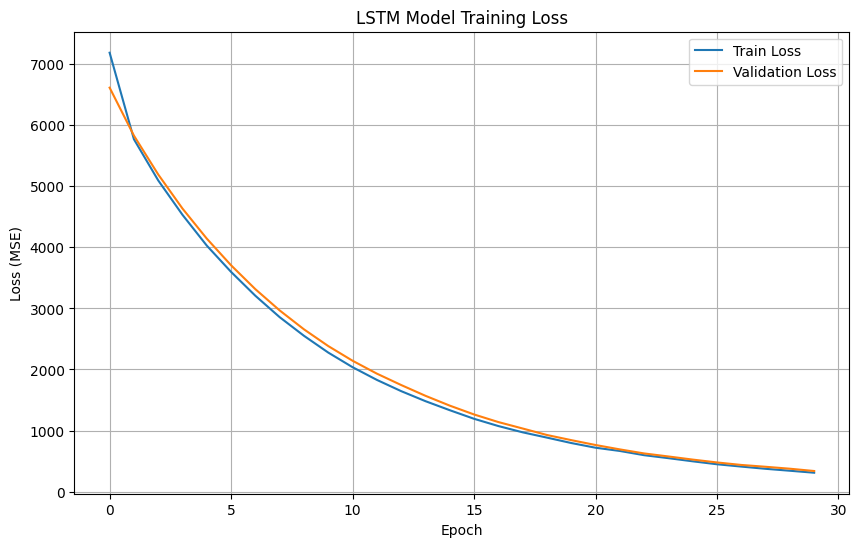

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()
